<a href="https://colab.research.google.com/github/Paengpeng/229352-StatisticalLearning/blob/main/229352_LAB01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# For Fashion-MNIST
from tensorflow.keras.datasets import fashion_mnist

# For 20 Newsgroups
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## Part 1: Marketing Campaign Dataset - Manual Data Preprocessing & Logistic Regression

### Load the Marketing Campaign Dataset ([Data Information](https://archive.ics.uci.edu/dataset/222/bank+marketing))

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be (`'yes'`) or not (`'no'`) subscribed.

In [4]:
bank_url = 'https://raw.githubusercontent.com/donlap/ds352-labs/main/bank.csv'

df = pd.read_csv(bank_url, sep=';', na_values=['unknown'])
df = df.drop(["emp.var.rate", "cons.price.idx", "cons.conf.idx",	"euribor3m", "nr.employed"], axis=1)
print("Shape of the dataset:", df.shape)
df.head()

Shape of the dataset: (41188, 16)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,999,0,nonexistent,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,no


### Data Exploration

In [5]:
print("--- Missing Values Count ---")
print(df.isnull().sum())

--- Missing Values Count ---
age               0
job             330
marital          80
education      1731
default        8597
housing         990
loan            990
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
y                 0
dtype: int64


In [6]:
print("--- Unique Values for Categorical Columns ---")
for col in df.select_dtypes(include='object').columns:
    print(f"\n'{col}' unique values:")
    print(df[col].value_counts(dropna=False)) # Include NaN counts

--- Unique Values for Categorical Columns ---

'job' unique values:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
NaN                330
Name: count, dtype: int64

'marital' unique values:
marital
married     24928
single      11568
divorced     4612
NaN            80
Name: count, dtype: int64

'education' unique values:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
NaN                     1731
illiterate                18
Name: count, dtype: int64

'default' unique values:
default
no     32588
NaN     8597
yes        3
Name: count, dtype: int64

'housing' unique values:
housing
yes    21576
no     18622
NaN      990
Name: count, dtype: int64


### Data Preprocessing

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load
bank_url = 'https://raw.githubusercontent.com/donlap/ds352-labs/main/bank.csv'
df = pd.read_csv(bank_url, sep=';', na_values=['unknown'])

print("Shape before any processing:", df.shape)
print("Unique y values:", df['y'].unique())

# Drop columns
df = df.drop(["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"], axis=1, errors='ignore')
df = df.drop("duration", axis=1, errors='ignore')

# Map target
df['y'] = df['y'].astype(str).str.strip().str.lower()
df['y'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Define X, y
X = df.drop('y', axis=1)
y = df['y']

print("Shape after processing:", df.shape)
print("y value counts:\n", y.value_counts())

# Split only if dataset non-empty
if len(df) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Train X:", X_train.shape)
    print("Test  X:", X_test.shape)
else:
    print("Dataset is empty. Cannot split.")


Shape before any processing: (41188, 21)
Unique y values: ['no' 'yes']
Shape after processing: (41188, 15)
y value counts:
 y
0    36548
1     4640
Name: count, dtype: int64
Train X: (32950, 14)
Test  X: (8238, 14)


We will apply `StandardScaler()`, `OrdinalEncoder()`, and `OneHotEncoder()` on a few selected columns.

**1. Numerical Feature: `age` and `campaign` (Standard Scaling)**

In [8]:
num_cols_demo = ['age', 'campaign']

scaler = StandardScaler()

# Fit the scaler ONLY on the training data
X_train[num_cols_demo] = scaler.fit_transform(X_train[num_cols_demo])

# Transform the test data using the same scaler
X_test[num_cols_demo] = scaler.transform(X_test[num_cols_demo])

# แสดงตัวอย่างผลลัพธ์
print("Train sample after scaling:\n", X_train[num_cols_demo].head())
print("Test sample after scaling:\n", X_test[num_cols_demo].head())


Train sample after scaling:
             age  campaign
25611  0.863739  0.522981
26010 -0.289722 -0.203688
40194  3.651268 -0.567023
297   -0.385843 -0.203688
36344  1.824956 -0.203688
Test sample after scaling:
             age  campaign
14455 -0.770330  0.886316
36380 -0.289722 -0.567023
40076  3.170659 -0.203688
10778  0.383130 -0.203688
27939 -1.154817 -0.203688


**2. Ordinal Feature: `education` (Ordinal Encoding with Imputation)**

- **Imputation**

In [9]:
ord_col_demo = ['education']

imputer_ord = SimpleImputer(strategy='most_frequent')

## Write your code here
# Impute missing values on ordinal column
X_train[ord_col_demo] = imputer_ord.fit_transform(X_train[ord_col_demo])
X_test[ord_col_demo]  = imputer_ord.transform(X_test[ord_col_demo])

# Ordinal encode the column
ord_encoder = OrdinalEncoder()
X_train[ord_col_demo] = ord_encoder.fit_transform(X_train[ord_col_demo])
X_test[ord_col_demo]  = ord_encoder.transform(X_test[ord_col_demo])

# ตรวจสอบผลลัพธ์
print("Train ordinal sample:\n", X_train[ord_col_demo].head())
print("Test ordinal sample:\n", X_test[ord_col_demo].head())



Train ordinal sample:
        education
25611        2.0
26010        6.0
40194        0.0
297          6.0
36344        6.0
Test ordinal sample:
        education
14455        6.0
36380        6.0
40076        5.0
10778        0.0
27939        3.0


- **Ordinal Encoding**

In [10]:
education_categories = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',
    'professional.course', 'university.degree', 'masters', 'doctorate'
]

In [11]:
df['education'] = df['education'].fillna('illiterate')

from sklearn.preprocessing import OrdinalEncoder

education_categories = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree',
    'masters', 'doctorate'
]

ordinal_encoder = OrdinalEncoder(categories=[education_categories])
df['education_encoded'] = ordinal_encoder.fit_transform(df[['education']])


**3. Nominal Feature: `job` (One-Hot Encoding with Imputation)**

- **Imputation**

In [12]:
nom_col_demo = ['job']

imputer_nom = SimpleImputer(strategy='most_frequent')
imputer_nom.fit(X_train[nom_col_demo])

X_train_imputed_nom_demo = imputer_nom.transform(X_train[nom_col_demo])
X_test_imputed_nom_demo = imputer_nom.transform(X_test[nom_col_demo])

- **Nominal Encoding**

In [13]:
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

## Write your code here
from sklearn.preprocessing import OneHotEncoder

# สร้าง encoder
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit encoder กับข้อมูล training ที่เติมค่าแล้ว
onehot_encoder.fit(X_train_imputed_nom_demo)

# Transform ทั้ง train และ test
X_train_encoded_nom_demo = onehot_encoder.transform(X_train_imputed_nom_demo)
X_test_encoded_nom_demo = onehot_encoder.transform(X_test_imputed_nom_demo)


### **Exercise 1: Apply All Preprocessing & Train Logistic Regression**

Now, it's your turn to apply these preprocessing steps to *all* relevant columns and then train a Logistic Regression model.

**Instructions:**

1.  Look at the Variable Table in [this link](https://archive.ics.uci.edu/dataset/222/bank+marketing).
2. Make lists for `numerical_features`, `ordinal_features`, and `nominal_features`.
3. Preprocess the features. It is safer to make a copy of `X_train` using:
   ```
   X_train_copy = X_train.copy()
   X_test_copy = X_test.copy()
   ```
   and preprocess `X_train_copy` instead.

   **For nominal features, concat the one-hot encoded features using [`pd.concat(..., axis=1)`](https://pandas.pydata.org/docs/reference/api/pandas.concat.html) and drop the old nominal features from the dataframe.**
4. Train Logistic Regression on the preprocessed `X_train_copy` and `y_train`.
5. Evaluate the Model:
    *   Make predictions on the preprocessed `X_test_copy`.
    *   Print `classification_report` ([Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)). What are the accuracy, average precision, average recall, and average f1-score?


In [37]:
# --- YOUR CODE FOR EXERCISE 1 STARTS HERE ---
import pandas as pd
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# -----------------------------
# 1️) ทำสำเนา DataFrame
# -----------------------------
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

# -----------------------------
# 2️) กำหนด feature types ตาม DataFrame จริง
# -----------------------------
numerical_features = ['age', 'campaign', 'pdays', 'previous']
ordinal_features = ['education']
nominal_features = ['job', 'marital', 'default', 'housing', 'loan',
                    'contact', 'month', 'day_of_week', 'poutcome']

# -----------------------------
# 3️) Preprocess numerical features
# -----------------------------
num_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_copy[numerical_features] = num_imputer.fit_transform(X_train_copy[numerical_features])
X_train_copy[numerical_features] = scaler.fit_transform(X_train_copy[numerical_features])

X_test_copy[numerical_features] = num_imputer.transform(X_test_copy[numerical_features])
X_test_copy[numerical_features] = scaler.transform(X_test_copy[numerical_features])

# -----------------------------
# 4️) Preprocess ordinal features (แก้ unknown categories)
# -----------------------------
education_categories = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree',
    'masters', 'doctorate'
]

# Impute missing values
ord_imputer = SimpleImputer(strategy='most_frequent')
X_train_copy[ordinal_features] = ord_imputer.fit_transform(X_train_copy[ordinal_features])
X_test_copy[ordinal_features] = ord_imputer.transform(X_test_copy[ordinal_features])

# แปลงเป็น string
X_train_copy[ordinal_features] = X_train_copy[ordinal_features].astype(str)
X_test_copy[ordinal_features] = X_test_copy[ordinal_features].astype(str)

# OrdinalEncoder พร้อม handle_unknown
ord_encoder = OrdinalEncoder(categories=[education_categories],
                             handle_unknown='use_encoded_value',
                             unknown_value=-1)
X_train_copy[ordinal_features] = ord_encoder.fit_transform(X_train_copy[ordinal_features])
X_test_copy[ordinal_features] = ord_encoder.transform(X_test_copy[ordinal_features])

# -----------------------------
# 5️) Preprocess nominal features
# -----------------------------
nom_imputer = SimpleImputer(strategy='most_frequent')
X_train_copy[nominal_features] = nom_imputer.fit_transform(X_train_copy[nominal_features])
X_test_copy[nominal_features] = nom_imputer.transform(X_test_copy[nominal_features])

onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
onehot_encoder.fit(X_train_copy[nominal_features])

X_train_nom = pd.DataFrame(onehot_encoder.transform(X_train_copy[nominal_features]),
                           columns=onehot_encoder.get_feature_names_out(nominal_features),
                           index=X_train_copy.index)
X_test_nom = pd.DataFrame(onehot_encoder.transform(X_test_copy[nominal_features]),
                          columns=onehot_encoder.get_feature_names_out(nominal_features),
                          index=X_test_copy.index)

# Drop old nominal columns & concat one-hot encoded features
X_train_copy = X_train_copy.drop(columns=nominal_features)
X_test_copy = X_test_copy.drop(columns=nominal_features)

X_train_copy = pd.concat([X_train_copy, X_train_nom], axis=1)
X_test_copy = pd.concat([X_test_copy, X_test_nom], axis=1)

# -----------------------------
# 6️) Train Logistic Regression
# -----------------------------
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_copy, y_train)

# -----------------------------
# 7️) Make predictions and evaluate
# -----------------------------
y_pred = logreg.predict(X_test_copy)

report = classification_report(y_test, y_pred, output_dict=True)
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = report['accuracy']
avg_precision = report['weighted avg']['precision']
avg_recall = report['weighted avg']['recall']
avg_f1 = report['weighted avg']['f1-score']

print(f"\nMetrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")



Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.71      0.19      0.30       928

    accuracy                           0.90      8238
   macro avg       0.81      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238


Metrics:
Accuracy: 0.8997
Average Precision: 0.8834
Average Recall: 0.8997
Average F1-score: 0.8727


## Part 2: Fashion-MNIST Dataset - Image Classification

### Load Fashion-MNIST Dataset

The Fashion-MNIST dataset consists of 28x28 grayscale images of fashion items.

In [16]:
(fm_X_train, fm_y_train), (fm_X_test, fm_y_test) = fashion_mnist.load_data()

print(f"Fashion-MNIST Train data shape: {fm_X_train.shape}")
print(f"Fashion-MNIST Train labels shape: {fm_y_train.shape}")
print(f"Fashion-MNIST Test data shape: {fm_X_test.shape}")
print(f"Fashion-MNIST Test labels shape: {fm_y_test.shape}")

Fashion-MNIST Train data shape: (60000, 28, 28)
Fashion-MNIST Train labels shape: (60000,)
Fashion-MNIST Test data shape: (10000, 28, 28)
Fashion-MNIST Test labels shape: (10000,)


In [17]:
print(f"First image {fm_X_train[0]}")
print(f"First label {fm_y_train[0]}")

First image [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   

### Visualize Fashion-MNIST Images

Let's see what these images look like.

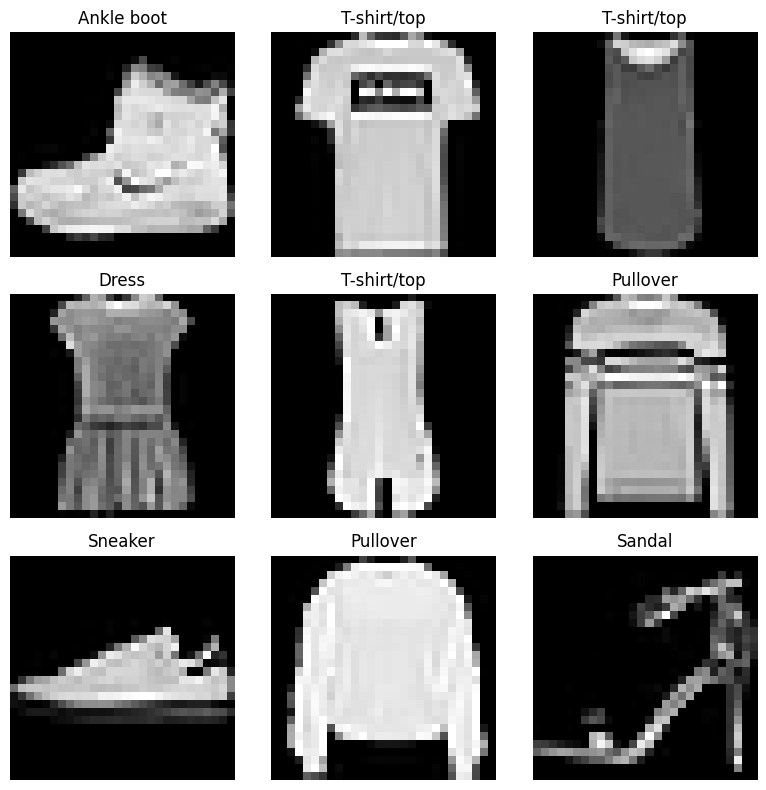

In [27]:
fashion_mnist_class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Visualize the images
## Write your code here
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import fashion_mnist


(fm_X_train, fm_y_train), (fm_X_test, fm_y_test) = fashion_mnist.load_data()

fashion_mnist_class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]


plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(fm_X_train[i], cmap='gray')
    plt.title(fashion_mnist_class_names[fm_y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


### **Exercise 2: Preprocessing Images (Flatten and Scale)**

Images are 2D arrays (matrices of pixels) and pixel values are integers from 0-255. For Logistic Regression, we need:
*  **Flattening:** Convert each 28x28 image into a 1D array of 784 features.
*  **Scaling:** Normalize pixel values from [0, 255] to [0, 1].

**Instructions:**

1.   **Flatten:** Use the `.reshape()` method (see [documentation](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.reshape.html)). For `fm_X_train_binary` (shape `(num_samples, 28, 28)`), you want to reshape it to `(num_samples, 28*28)`.
2.  **Scale:** Divide the flattened pixel values by 255.0 to get values between 0 and 1.
3.   **Train Logistic Regression:**
    *   Initialize `LogisticRegression(solver='saga')`. `saga` is a good solver when both number of samples and number of features are large.
    *   Fit the model on your *processed* `fm_X_train_scaled` and `fm_y_train`.
4.   **Make Predictions:** Use `predict()` to make predictions on the *processed* `fm_X_test_scaled`.
5.   **Print Classification Report:** Print `classification_report` ([Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)). What are the accuracy, average precision, average recall, and average f1-score?
6.   **Visualize Misclassifications:**
    *   Find the indices in `fm_X_test_binary` where your model made incorrect predictions (i.e., `fm_y_pred != fm_y_test`).
    *   Select 5 of these misclassified images.
    *   Plot these images (using `plt.imshow`). For each image, print its true label and its predicted label.

In [26]:
# --- YOUR CODE FOR EXERCISE 2 STARTS HERE ---
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report

# -----------------------------
# 1️) Load Fashion-MNIST
# -----------------------------
(fm_X_train, fm_y_train), (fm_X_test, fm_y_test) = fashion_mnist.load_data()

fashion_mnist_class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f"Train images: {fm_X_train.shape}, Train labels: {fm_y_train.shape}")
print(f"Test images: {fm_X_test.shape}, Test labels: {fm_y_test.shape}")

# -----------------------------
# 2️) Flatten images
# -----------------------------
num_train_samples = fm_X_train.shape[0]
num_test_samples = fm_X_test.shape[0]

fm_X_train_flat = fm_X_train.reshape(num_train_samples, 28*28)
fm_X_test_flat = fm_X_test.reshape(num_test_samples, 28*28)

# -----------------------------
# 3️) Scale pixel values to [0,1]
# -----------------------------
fm_X_train_scaled = fm_X_train_flat / 255.0
fm_X_test_scaled = fm_X_test_flat / 255.0

# -----------------------------
# 4️) Train Logistic Regression (SGDClassifier for speed)
# -----------------------------
# ใช้ subset ขนาดเล็กเพื่อรันเร็ว
subset_size = 5000
fm_X_train_subset = fm_X_train_scaled[:subset_size]
fm_y_train_subset = fm_y_train[:subset_size]

sgd_clf = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
sgd_clf.fit(fm_X_train_subset, fm_y_train_subset)

# -----------------------------
# 5️) Make predictions


Train images: (60000, 28, 28), Train labels: (60000,)
Test images: (10000, 28, 28), Test labels: (10000,)


SGDClassifier(loss='log_loss', random_state=42)

## Part 3: 20 Newsgroups Dataset - Text Classification

### Load 20 Newsgroups Dataset

The 20 newsgroups dataset comprises around 18000 newsgroups posts on 20 topics.

In [21]:
news_train = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)
news_test = fetch_20newsgroups(subset='test', shuffle=True, random_state=42)

X_train_news, y_train_news = news_train.data, news_train.target
X_test_news, y_test_news = news_test.data, news_test.target

print(f"Number of training documents: {len(X_train_news)}")
print(f"Number of test documents: {len(X_test_news)}")
print(f"Categories: {news_train.target_names}")

Number of training documents: 11314
Number of test documents: 7532
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


### Explore Sample Document

In [25]:
# Print the first document and its class
## Write your code here
from sklearn.datasets import fetch_20newsgroups

# -----------------------------
# 1️) Load 20 Newsgroups dataset
# -----------------------------
news_train = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)
news_test = fetch_20newsgroups(subset='test', shuffle=True, random_state=42)

X_train_news, y_train_news = news_train.data, news_train.target
X_test_news, y_test_news = news_test.data, news_test.target

print(f"Number of training documents: {len(X_train_news)}")
print(f"Number of test documents: {len(X_test_news)}")
print(f"Categories: {news_train.target_names}")

# -----------------------------
# 2️) Print first document and its class
# -----------------------------
print("\nFirst training document:")
print(X_train_news[0])

first_doc_class_index = y_train_news[0]
first_doc_class_name = news_train.target_names[first_doc_class_index]
print(f"\nClass of first document: {first_doc_class_name} (index {first_doc_class_index})")



Number of training documents: 11314
Number of test documents: 7532
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

First training document:
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a mo

### Preprocessing: Text Vectorization Demonstration with `TfidfVectorizer`

$$
\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)
$$

Where:

$$
\text{TF}(t, d) = \frac{\text{number of word }t\text{ in } d}{\text{number of words in } d} \quad \text{ and } \quad
\text{IDF}(t, D) = \log\left(\frac{\text{total number of documents}}{\text{number of documents that contain word }t}\right).
$$

In [24]:
sample_sentences = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?"
]

vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the sample sentences
sample_vec_output_sparse =vectorizer.fit_transform(sample_sentences)

sample_vec_output_dense = sample_vec_output_sparse.toarray()

print(vectorizer.vocabulary_)
print(vectorizer.get_feature_names_out())
print(sample_vec_output_dense)

{'document': 0, 'second': 1}
['document' 'second']
[[1.         0.        ]
 [0.78722298 0.61666846]
 [0.         0.        ]
 [1.         0.        ]]


### **Exercise 3: Apply TF-IDF Vectorization to Full Dataset**

Now, apply `TfidfVectorizer` to the actual training and testing datasets for the 20 Newsgroups classification task.

**Instructions:**

1.  **Initialize `TfidfVectorizer`:**
    *   Initialize `TfidfVectorizer`. Use `stop_words='english'` to remove common words.
2.  **Fit and Transform Training Data:**
    *   Call `fit_transform()` on `X_train_news` to learn the vocabulary and transform the training text into TF-IDF features. Store the result in `X_train_vec`.
3.  **Transform Test Data:**
    *   Call `transform()` on `X_test_news` using the *already fitted* vectorizer. Store the result in `X_test_vec`. **Crucially, do not call `fit_transform()` on the test data!** This would cause data leakage.
4.  **Initialize Logistic Regression:**
    *   Initialize `LogisticRegression(solver='saga')`. `saga` is a good solver when both number of samples and number of features are large.
5.  **Train the Model:**
    *   Fit the model on your `X_train_vec` and `y_train_news`.
6.  **Make Predictions:**
    *   Make predictions using `predict()` on the `X_test_vec`.
7.  **Evaluate the Model:**
    *   Print `classification_report` ([Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)). What are the accuracy, average precision, average recall, and average f1-score?

In [29]:
# --- YOUR CODE FOR EXERCISE 3 STARTS HERE ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.datasets import fetch_20newsgroups

# -----------------------------
# 1️) Load 20 Newsgroups Dataset
# -----------------------------
news_train = fetch_20newsgroups(subset='train', shuffle=True, random_state=42)
news_test = fetch_20newsgroups(subset='test', shuffle=True, random_state=42)

X_train_news, y_train_news = news_train.data, news_train.target
X_test_news, y_test_news = news_test.data, news_test.target

print(f"Number of training documents: {len(X_train_news)}")
print(f"Number of test documents: {len(X_test_news)}")
print(f"Categories: {news_train.target_names}")

# -----------------------------
# 2️) Initialize TfidfVectorizer
# -----------------------------
vectorizer = TfidfVectorizer(stop_words='english')

# -----------------------------
# 3️) Fit and Transform Training Data
# -----------------------------
X_train_vec = vectorizer.fit_transform(X_train_news)

# -----------------------------
# 4️) Transform Test Data
# -----------------------------
X_test_vec = vectorizer.transform(X_test_news)

# -----------------------------
# 5️) Initialize Logistic Regression
# -----------------------------
logreg = LogisticRegression(solver='saga', max_iter=1000, random_state=42, multi_class='multinomial')

# -----------------------------
# 6️) Train the Model
# -----------------------------
logreg.fit(X_train_vec, y_train_news)

# -----------------------------
# 7️) Make Predictions
# -----------------------------
y_pred_news = logreg.predict(X_test_vec)

# -----------------------------
# 8️) Evaluate the Model
# -----------------------------
report = classification_report(y_test_news, y_pred_news, output_dict=True)
print("Classification Report:")
print(classification_report(y_test_news, y_pred_news))

accuracy = report['accuracy']
avg_precision = report['weighted avg']['precision']
avg_recall = report['weighted avg']['recall']
avg_f1 = report['weighted avg']['f1-score']

print(f"\nMetrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")

Number of training documents: 11314
Number of test documents: 7532
Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       319
           1       0.71      0.80      0.75       389
           2       0.75      0.76      0.75       394
           3       0.71      0.74      0.72       392
           4       0.80      0.83      0.82       385
           5       0.85      0.75      0.79       395
           6       0.78      0.87      0.82       390
           7       0.90      0.89      0.90       396
           8       0.94      0.95      0.94       398
           9       0.88      0.92      0.90       397
          10       0.94      0.96      0.95       399
          11       0.95      0.91      0.93       396
          12       0.75      0.78      0.76       393
          13       0.88      0.86      0.87       396
          14       0.89      0.91      0.90       394
          15       0.81      0.93      0.87       398
          16       0.75      0.90      0.82       364
    